<h1 dir=rtl align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
نرمال‌سازی دسته‌ای و لایه‌ای
</font>
</h1>

In [1]:
import keras
import matplotlib.pyplot as plt

In [2]:
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

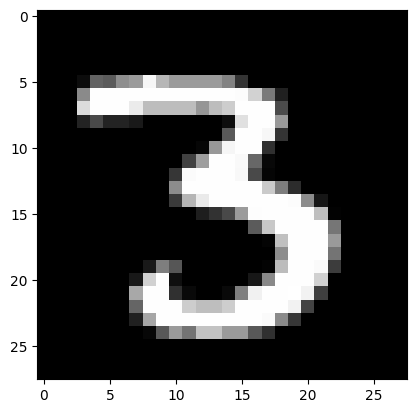

In [3]:
plt.imshow(X_train[12], cmap = plt.get_cmap('gray'))

In [4]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
نرمال‌سازی دسته‌ای (Batch Normalization)
</font>
</h2>

<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پس از تابع فعال‌ساز
</font>
</h3>

In [6]:
model1 = keras.Sequential()
model1.add(keras.layers.Input(shape=(28, 28)))
model1.add(keras.layers.Flatten())
model1.add(keras.layers.Dense(128, activation='relu'))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dense(256, activation='relu'))
model1.add(keras.layers.BatchNormalization())
model1.add(keras.layers.Dense(10, activation='softmax'))

In [7]:
model1.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 128)               100480    
                                                                 
 batch_normalization_4 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_7 (Dense)             (None, 256)               33024     
                                                                 
 batch_normalization_5 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dense_8 (Dense)             (None, 10)               

In [8]:
model1.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [9]:
model1.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 [==============================] - 11s 5ms/step - loss: 0.3284 - accuracy: 0.9004 - val_loss: 0.1323 - val_accuracy: 0.9627
Epoch 2/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1670 - accuracy: 0.9500 - val_loss: 0.1040 - val_accuracy: 0.9703
Epoch 3/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1309 - accuracy: 0.9611 - val_loss: 0.0894 - val_accuracy: 0.9743
Epoch 4/10
1688/1688 [==============================] - 8s 4ms/step - loss: 0.1062 - accuracy: 0.9683 - val_loss: 0.0855 - val_accuracy: 0.9765
Epoch 5/10
1688/1688 [==============================] - 9s 6ms/step - loss: 0.0903 - accuracy: 0.9731 - val_loss: 0.0790 - val_accuracy: 0.9765
Epoch 6/10
1688/1688 [==============================] - 13s 8ms/step - loss: 0.0766 - accuracy: 0.9770 - val_loss: 0.0778 - val_accuracy: 0.9777
Epoch 7/10
1688/1688 [==============================] - 13s 7ms/step - loss: 0.0686 - accuracy: 0.9794 - val_loss: 0.0759 - val_accura

In [10]:
loss_and_metrics = model1.evaluate(X_test, y_test, batch_size=128)

79/79 [==============================] - 0s 3ms/step - loss: 0.0751 - accuracy: 0.9758


<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پیش از تابع فعال‌ساز
</font>
</h3>

In [11]:
model2 = keras.Sequential()
model2.add(keras.layers.Input(shape=(28, 28)))
model2.add(keras.layers.Flatten())
model2.add(keras.layers.Dense(128))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('relu'))
model2.add(keras.layers.Dense(256))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('relu'))
model2.add(keras.layers.Dense(10, activation='softmax'))

In [12]:
model2.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_9 (Dense)             (None, 128)               100480    
                                                                 
 batch_normalization_6 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 activation (Activation)     (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 256)               33024     
                                                                 
 batch_normalization_7 (Bat  (None, 256)               1024      
 chNormalization)                                     

In [13]:
model2.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [14]:
model2.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4107 - accuracy: 0.8821 - val_loss: 0.1607 - val_accuracy: 0.9560
Epoch 2/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.2106 - accuracy: 0.9388 - val_loss: 0.1207 - val_accuracy: 0.9668
Epoch 3/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1630 - accuracy: 0.9533 - val_loss: 0.1039 - val_accuracy: 0.9710
Epoch 4/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1361 - accuracy: 0.9607 - val_loss: 0.0903 - val_accuracy: 0.9748
Epoch 5/10
1688/1688 [==============================] - 7s 4ms/step - loss: 0.1164 - accuracy: 0.9658 - val_loss: 0.0831 - val_accuracy: 0.9757
Epoch 6/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1037 - accuracy: 0.9696 - val_loss: 0.0772 - val_accuracy: 0.9767
Epoch 7/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0922 - accuracy: 0.9731 - val_loss: 0.0748 - val_accuracy:

In [15]:
loss_and_metrics = model2.evaluate(X_test, y_test, batch_size=128)

79/79 [==============================] - 0s 5ms/step - loss: 0.0757 - accuracy: 0.9753


<h3 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بدون بایاس
</font>
</h3>

In [16]:
model3 = keras.Sequential()
model3.add(keras.layers.Input(shape=(28, 28)))
model3.add(keras.layers.Flatten())
model3.add(keras.layers.Dense(128, use_bias=False))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('relu'))
model3.add(keras.layers.Dense(256, use_bias=False))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('relu'))
model3.add(keras.layers.Dense(10, activation='softmax'))

In [17]:
model3.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 128)               100352    
                                                                 
 batch_normalization_8 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 activation_2 (Activation)   (None, 128)               0         
                                                                 
 dense_13 (Dense)            (None, 256)               32768     
                                                                 
 batch_normalization_9 (Bat  (None, 256)               1024      
 chNormalization)                                     

In [18]:
model3.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [19]:
model3.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 [==============================] - 9s 5ms/step - loss: 0.4138 - accuracy: 0.8828 - val_loss: 0.1574 - val_accuracy: 0.9583
Epoch 2/10
1688/1688 [==============================] - 10s 6ms/step - loss: 0.2058 - accuracy: 0.9404 - val_loss: 0.1149 - val_accuracy: 0.9693
Epoch 3/10
1688/1688 [==============================] - 9s 5ms/step - loss: 0.1592 - accuracy: 0.9531 - val_loss: 0.0954 - val_accuracy: 0.9735
Epoch 4/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1315 - accuracy: 0.9619 - val_loss: 0.0872 - val_accuracy: 0.9760
Epoch 5/10
1688/1688 [==============================] - 11s 6ms/step - loss: 0.1135 - accuracy: 0.9673 - val_loss: 0.0808 - val_accuracy: 0.9765
Epoch 6/10
1688/1688 [==============================] - 10s 6ms/step - loss: 0.1000 - accuracy: 0.9707 - val_loss: 0.0739 - val_accuracy: 0.9788
Epoch 7/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0903 - accuracy: 0.9739 - val_loss: 0.0727 - val_accura

In [20]:
loss_and_metrics = model3.evaluate(X_test, y_test, batch_size=128)

79/79 [==============================] - 0s 3ms/step - loss: 0.0761 - accuracy: 0.9762


<h2 dir=rtl align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
نرمال‌سازی لایه‌ای (Layer Normalization)
</font>
</h2>

In [21]:
model4 = keras.Sequential()
model4.add(keras.layers.Input(shape=(28, 28)))
model4.add(keras.layers.Flatten())
model4.add(keras.layers.Dense(128, activation='relu'))
model4.add(keras.layers.LayerNormalization())
model4.add(keras.layers.Dense(256, activation='relu'))
model4.add(keras.layers.LayerNormalization())
model4.add(keras.layers.Dense(10, activation='softmax'))

In [22]:
model4.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 dense_15 (Dense)            (None, 128)               100480    
                                                                 
 layer_normalization (Layer  (None, 128)               256       
 Normalization)                                                  
                                                                 
 dense_16 (Dense)            (None, 256)               33024     
                                                                 
 layer_normalization_1 (Lay  (None, 256)               512       
 erNormalization)                                                
                                                                 
 dense_17 (Dense)            (None, 10)               

In [23]:
model4.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [24]:
model4.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 [==============================] - 10s 5ms/step - loss: 0.2986 - accuracy: 0.9109 - val_loss: 0.1393 - val_accuracy: 0.9617
Epoch 2/10
1688/1688 [==============================] - 8s 4ms/step - loss: 0.1398 - accuracy: 0.9586 - val_loss: 0.1090 - val_accuracy: 0.9700
Epoch 3/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.1007 - accuracy: 0.9702 - val_loss: 0.0912 - val_accuracy: 0.9733
Epoch 4/10
1688/1688 [==============================] - 7s 4ms/step - loss: 0.0788 - accuracy: 0.9768 - val_loss: 0.0941 - val_accuracy: 0.9722
Epoch 5/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0641 - accuracy: 0.9820 - val_loss: 0.0791 - val_accuracy: 0.9752
Epoch 6/10
1688/1688 [==============================] - 8s 5ms/step - loss: 0.0517 - accuracy: 0.9860 - val_loss: 0.0781 - val_accuracy: 0.9770
Epoch 7/10
1688/1688 [==============================] - 7s 4ms/step - loss: 0.0434 - accuracy: 0.9882 - val_loss: 0.0739 - val_accuracy

In [25]:
loss_and_metrics = model4.evaluate(X_test, y_test, batch_size=128)

79/79 [==============================] - 0s 6ms/step - loss: 0.0770 - accuracy: 0.9770
